In [1]:
"""Generate image with flight track superimposed on GOES visible image"""

from orcestra.flightplan import  LatLon, path_preview
from orcestra.weathermaps import goes_overlay
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import xarray as xr
sns.set_context("talk")

/opt/homebrew/Caskroom/miniforge/base/envs/orcestra/lib/python3.12/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


 ╭─goes2go──────────────────────────────────────────────╮
 │ INFO: Created a default config file.                 │
 │ You may view/edit goes2go's configuration here:      │
 │   /Users/jakobdeutloff/.config/goes2go/config.toml   │
 ╰──────────────────────────────────────────────────────╯



/opt/homebrew/Caskroom/miniforge/base/envs/orcestra/lib/python3.12/site-packages/goes2go/data.py:665: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  within=pd.to_timedelta(config["nearesttime"].get("within", "1h")),
/opt/homebrew/Caskroom/miniforge/base/envs/orcestra/lib/python3.12/site-packages/goes2go/NEW.py:188: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  within=pd.to_timedelta(config["nearesttime"].get("within", "1h")),


📦 Finished downloading [1] files to [/Users/jakobdeutloff/data/noaa-goes16/ABI-L2-MCMIPF].
📚 Finished reading [1] files into xarray.Dataset.                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

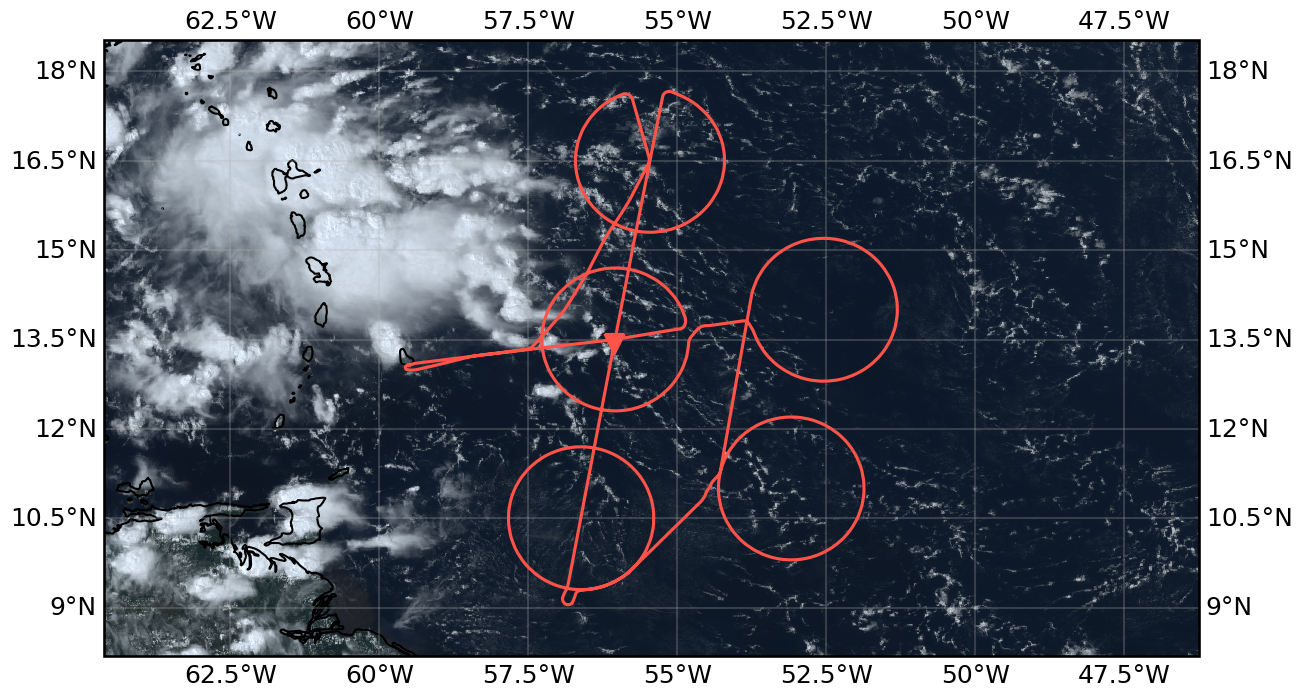

In [2]:
flight_name = 'HALO-20240926a'
flight_date = flight_name[5:9]+'-'+flight_name[9:11]+'-'+flight_name[11:13]

tracks = xr.open_dataset(f"ipns://latest.orcestra-campaign.org/products/HALO/position_attitude/{flight_name}.zarr",
                engine="zarr")
path   = LatLon(lat=tracks['lat'], lon=tracks['lon'], label=flight_name)

sat_date_time = flight_date+'T17:51'
loc_at_sat = tracks.assign_coords({"tid" : tracks.time}).sel(time = sat_date_time, method = "nearest")

fig, ax = plt.subplots(
    figsize=(15, 8),
    facecolor='white',
    subplot_kw  ={"projection": ccrs.PlateCarree()}
)

path_preview(path,ax=ax,show_waypoints=False,color='#FF5349')

sat_lon, sat_lat = float(loc_at_sat.lon.values), float(loc_at_sat.lat.values)
plt.scatter(sat_lon, sat_lat, color='#FF5349', marker='v', s = 200)

# goes_overlay can take some time depending on the network.  The downloaded image is cached, but the first time
# it can take 15 min to download.  Thereafter the fetching and plotting of the cached data takes about 1 min
#
goes_overlay(sat_date_time,ax)
fig.savefig(flight_name+'-track.jpeg',bbox_inches='tight')